In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [47]:
df = pd.read_csv("/content/Diwali Sales Data.csv", encoding='unicode_escape')

In [48]:
df.head(10)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,NaN
5,1000588,Joni,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00,NaN,NaN
6,1001132,Balk,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00,NaN,NaN
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN,NaN,NaN
8,1003224,Kushal,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00,NaN,NaN
9,1003650,Ginny,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99,NaN,NaN


In [49]:
#Provide the description of whole data
df.describe()

#Use desc for specific columns

df[["Amount" , "Orders" , "Age"]].describe()

,Amount,Orders,Age
count,11239.000000,11251.000000,11251.000000
mean,9453.610858,2.489290,35.421207
std,5222.355869,1.115047,12.754122
min,188.000000,1.000000,12.000000
25%,5443.000000,1.500000,27.000000
50%,8109.000000,2.000000,33.000000
75%,12675.000000,3.000000,43.000000
max,23952.000000,4.000000,92.000000


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [51]:
#See that the Status and Unamed have null Values?? axis 1 means whole column and axis 0 is for row??
#drop unrelaed columns and blanks
df.drop(['Status', 'unnamed1'] , axis = 1 , inplace = True)

In [52]:
#Check the null values
df.isnull().sum()

,0
User_ID,0
Cust_name,0
Product_ID,0
Gender,0
Age Group,0
Age,0
Marital_Status,0
State,0
Zone,0
Occupation,0


In [53]:
#drop the null values
df.dropna(inplace = True)


In [54]:
df.shape

(11239, 13)

In [55]:
#How to change the  datatype of amount column float to Int using "Astype"
df["Amount"]= df["Amount"].astype("int")

In [56]:
df["Amount"].dtypes

dtype('int64')

In [57]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [58]:
#How to rename the column and just to save into any variable??
df.rename(columns = {"Marital_Status" : "Shaddi"})

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Shaddi,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206


##**Exploratory Data Analysis**

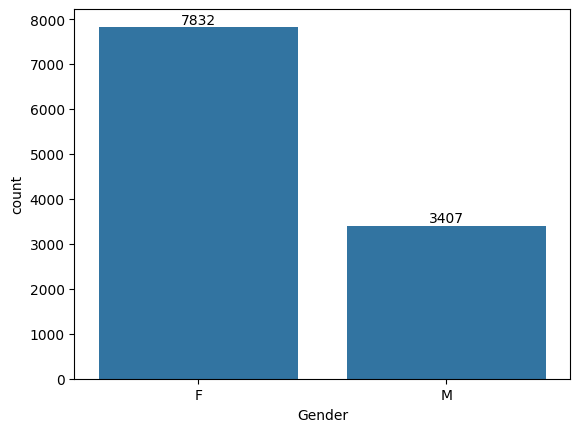

In [60]:
#Plot a Countplot for "Gender"
axes = sns.countplot(x="Gender" , data =df)

#placed some labels
for bars in axes.containers:
  axes.bar_label(bars)

##From the below graph we can see that the most of buyers are **Female** rather than male along with the purchasing power as well...

<Axes: xlabel='Gender', ylabel='Amount'>

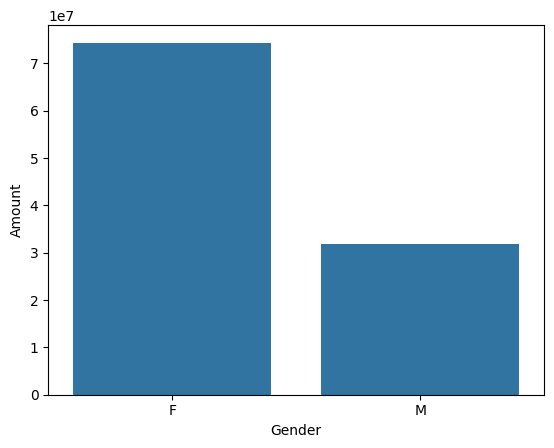

In [69]:
sales = df.groupby(["Gender"] , as_index = False)["Amount"].sum().sort_values(by = "Amount" , ascending = False)
sns.barplot(x = "Gender" , y = "Amount" , data =sales)


##With the below graph we have seen that most of the buyers are from the : **age group of 26-35 with higher level of feamle buyers**..


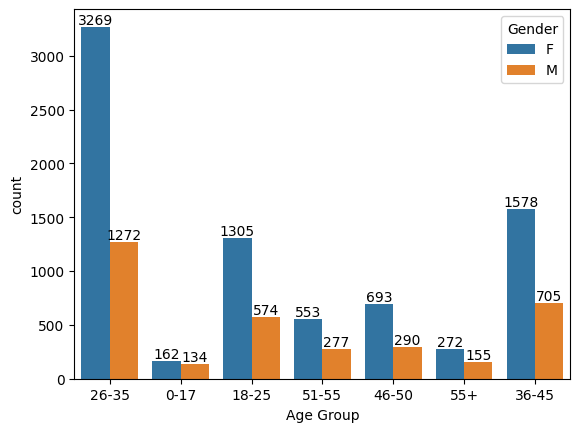

In [115]:
# Ages= df.groupby(["Age Group"], as_index = False)["Amount"].sum().sort_values(by =["Age Group", "Amount"], ascending= [True ,False ])
sales_ages = df.groupby(["Age Group"] , as_index = False)["Amount"].sum().sort_values(by = "Amount" , ascending = False)
ax = sns.countplot(x = "Age Group" ,data = df , hue = "Gender")

#Hue is just the RHS square box labels

#Same graph with values
for bars in ax.containers:
  ax.bar_label(bars)


##In this graph We have seen that: **Uttar Pradesh has the highest order count of 4807 rather than others**??

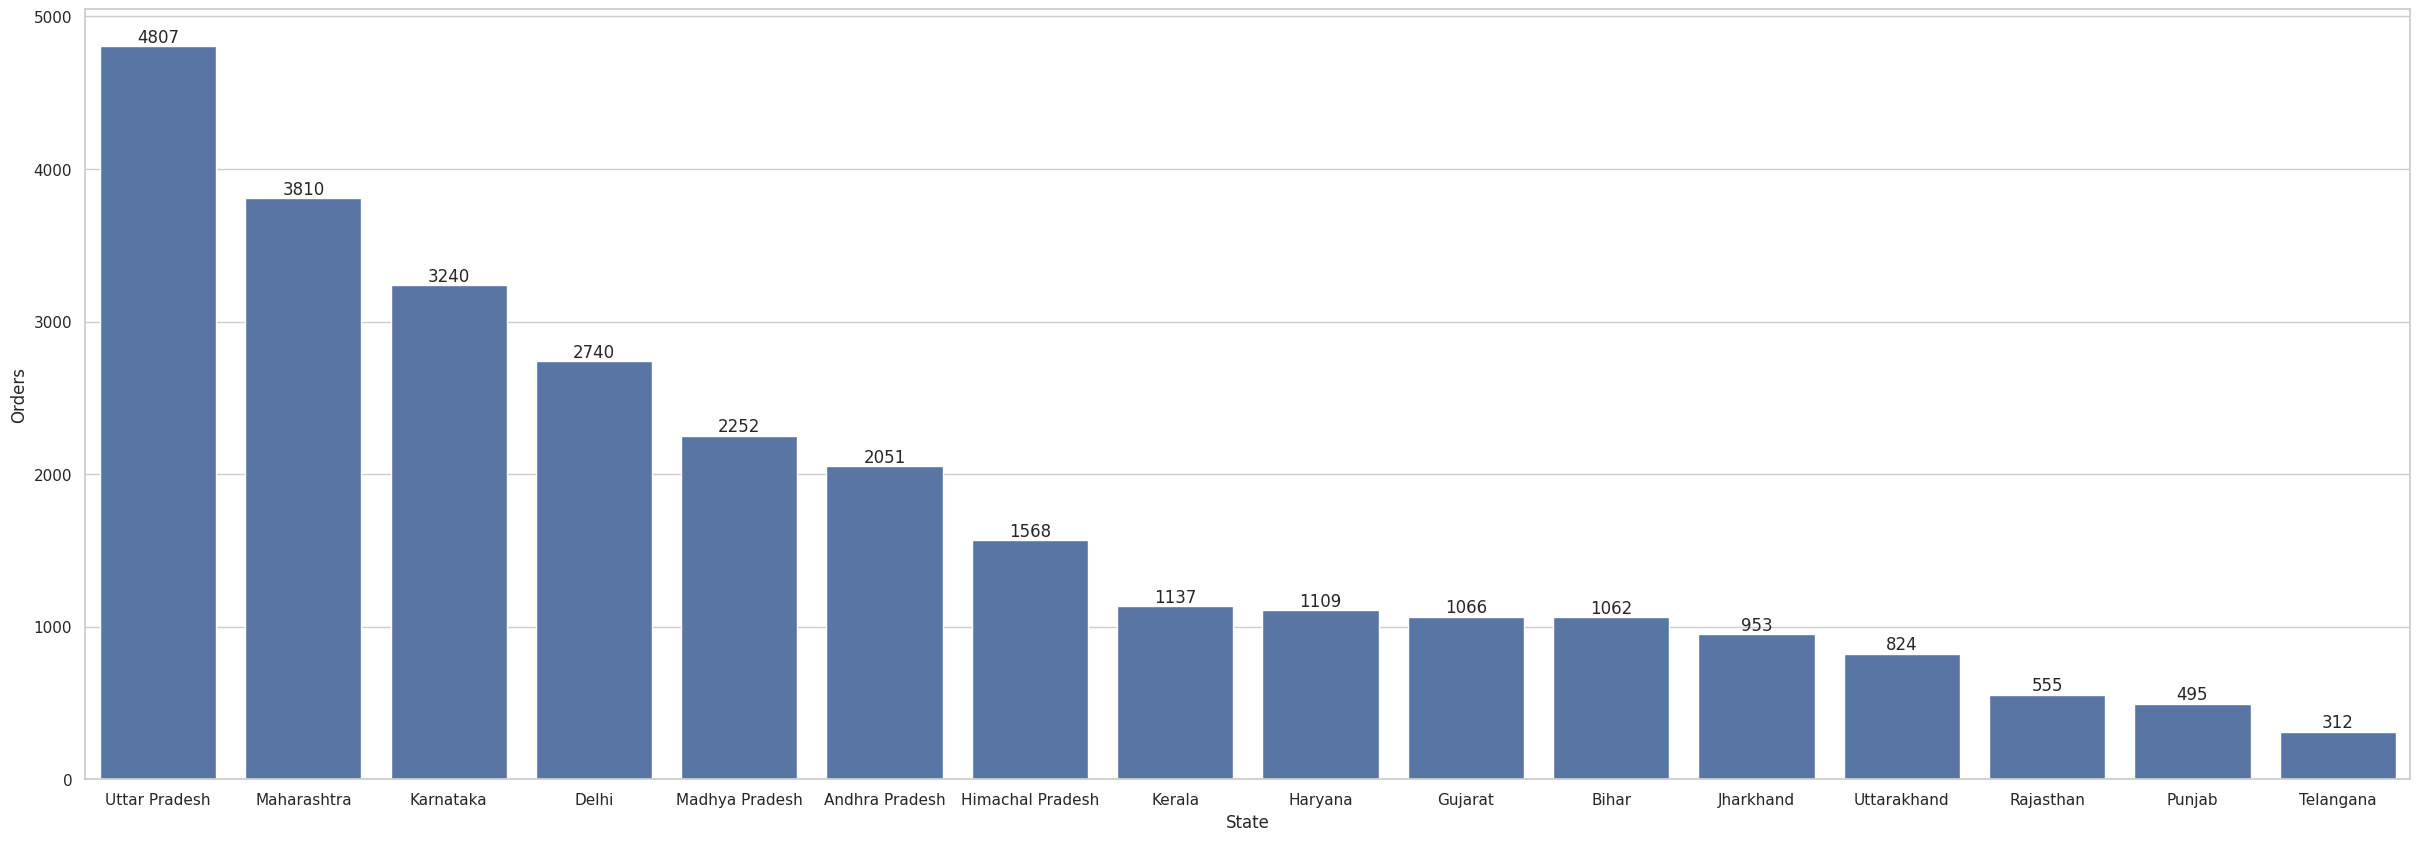

In [158]:
#Total Number of orders from top 10 states?? ["orders"] is specifying no. of orders
sales_states = df.groupby(["State"], as_index = False)["Orders"].sum().sort_values(by = "Orders" , ascending = False)

#How to set the figure Size..(Width and Height)
sns.set(rc={"figure.figsize":(30,10)})
sns.set_theme(style = "whitegrid")
sns.set_color_codes(palette = "dark")

#Barplot
ax = sns.barplot(data = sales_states , x ="State" , y = "Orders")

# sales_states.head(10).sort_values(by = "Orders")

#Labels
for bars in ax.containers:
  ax.bar_label(bars)

##Most of the orders are from the **Uttar Pradesh, Maharashtra and Karanataka respectively**

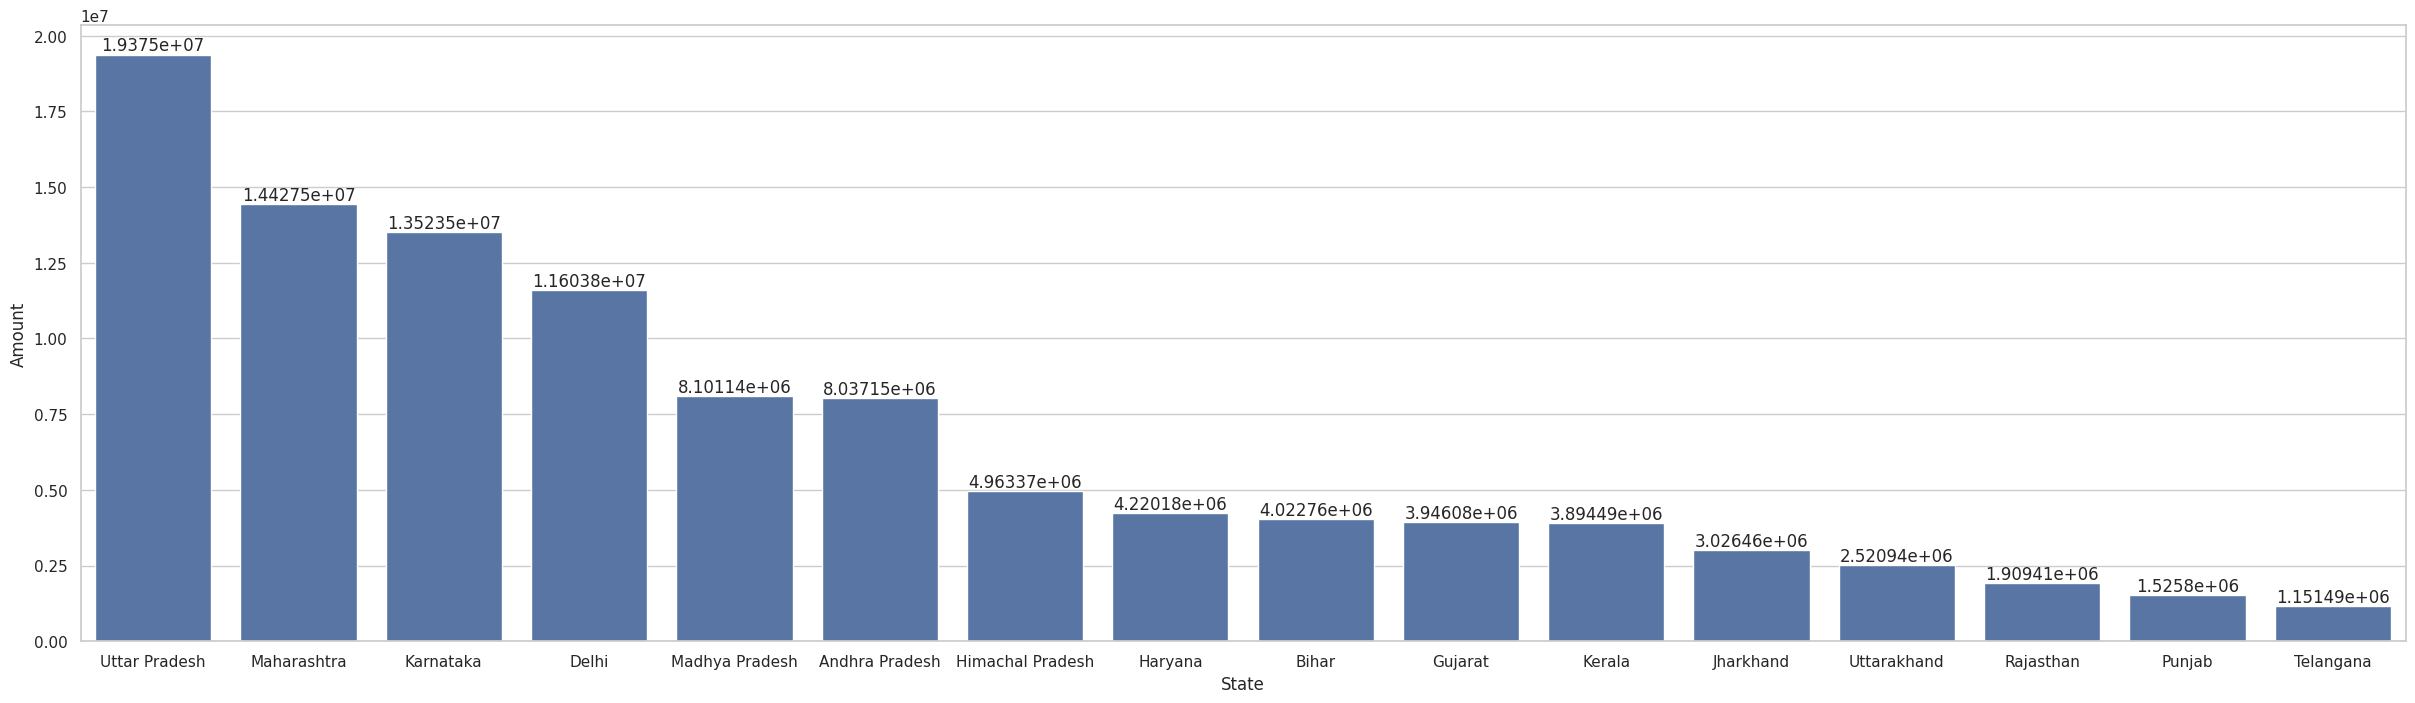

In [169]:
#Highest Number of Amounts  from top 10 states?? ["orders"] is specifying no. of orders
sales_states = df.groupby(["State"], as_index = False)["Amount"].sum().sort_values(by = "Amount" , ascending = False)

#How to set the figure Size..(Width and Height)
sns.set(rc={"figure.figsize":(30, 8)})
sns.set_theme(style = "whitegrid")
sns.set_color_codes(palette = "dark")

#Barplot
ax = sns.barplot(data = sales_states , x ="State" , y = "Amount")

# sales_states.head(10).sort_values(by = "Orders")

#Labels
for bars in ax.containers:
  ax.bar_label(bars)

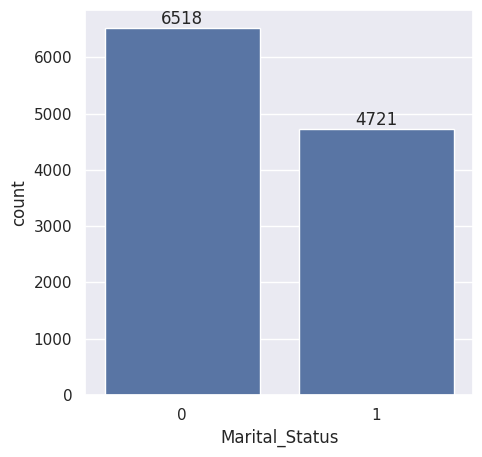

In [173]:
ax = sns.countplot(x ="Marital_Status" , data =df)
sns.set(rc={"figure.figsize": (5,2)})
for bars in ax.containers:
  ax.bar_label(bars)

##From this graph we have seen that the highest purchasing power of married(women)

<Axes: xlabel='Marital_Status', ylabel='Amount'>

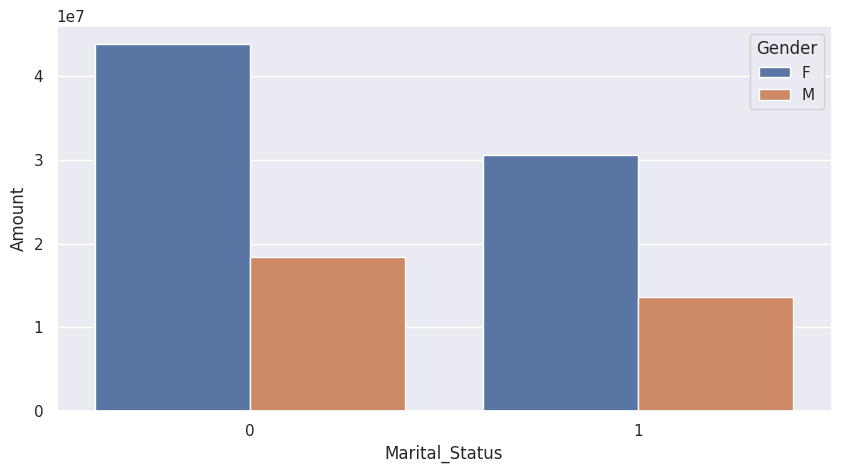

In [184]:
Marital_st = df.groupby(["Marital_Status" , "Gender"] , as_index = False)["Amount"].sum().sort_values(by = "Amount" , ascending = False)
sns.set(rc={"figure.figsize": (10,5)})
sns.barplot(x = 'Marital_Status', y= 'Amount' ,data = Marital_st, hue= "Gender")

##Occupation

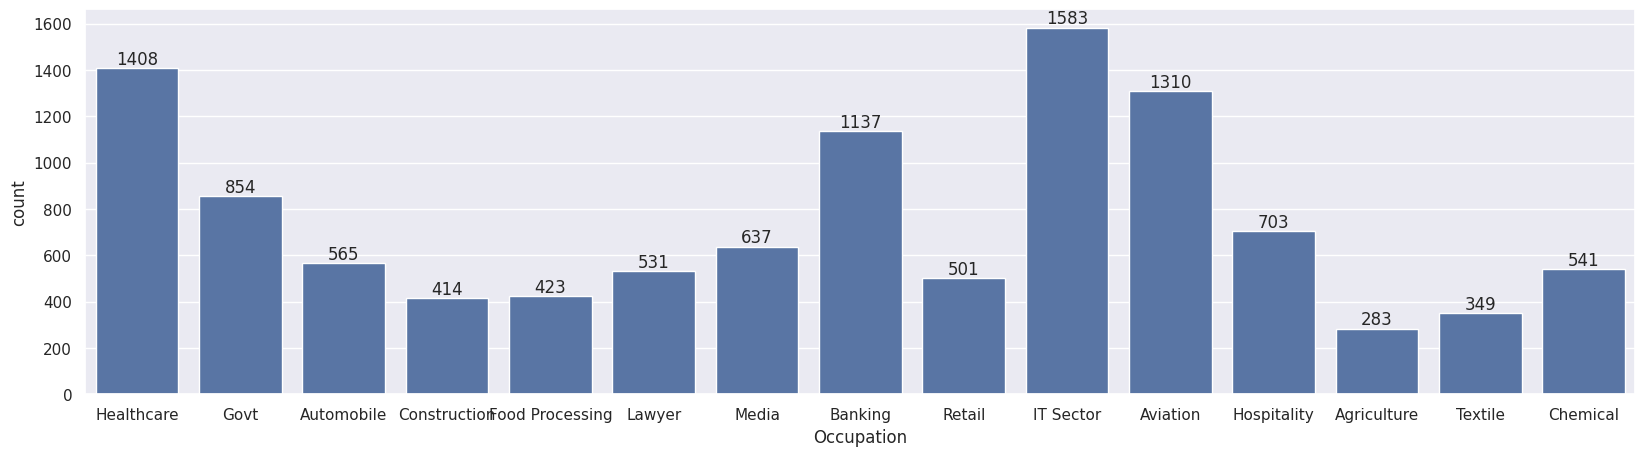

In [190]:
sns.set(rc={"figure.figsize": (20,5)})
ax = sns.countplot(x="Occupation" , data =df)

##We have seen that most of the buyers are from the **IT, Healthcare and Aviation Industry**

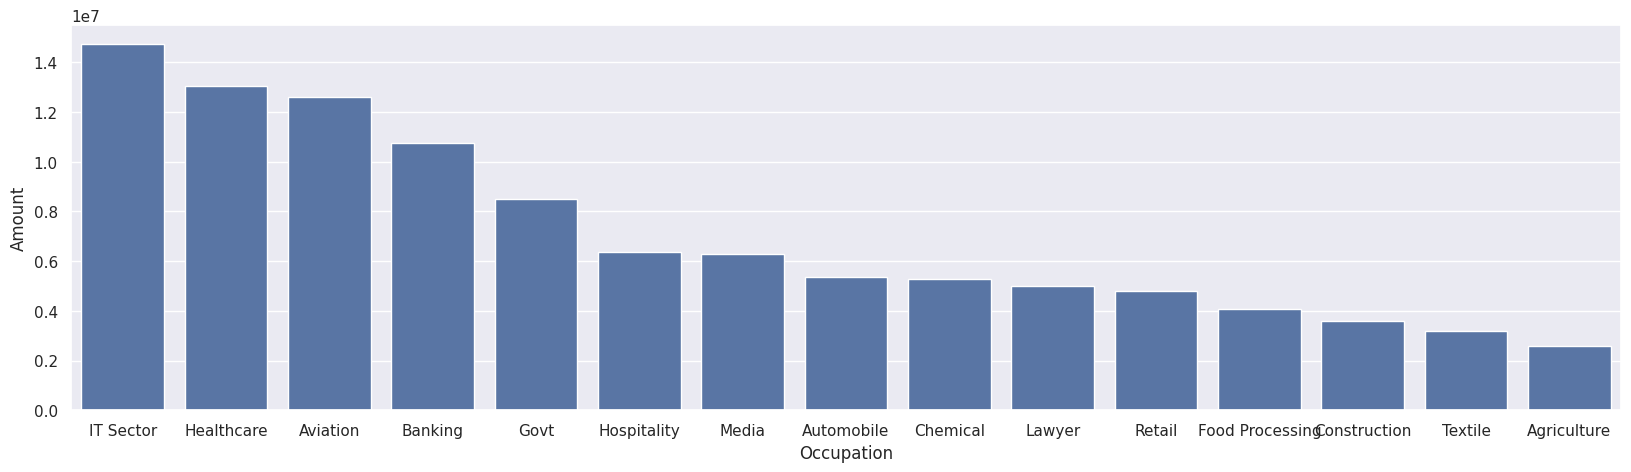

In [195]:
#Find the highest number of occupation with the amount??

sales_target = df.groupby(["Occupation"] ,as_index=False)["Amount"].sum().sort_values(by ="Amount", ascending = False)
ax = sns.barplot(x = "Occupation" , y = "Amount" , data = sales_target)

<Axes: xlabel='Product_Category', ylabel='count'>

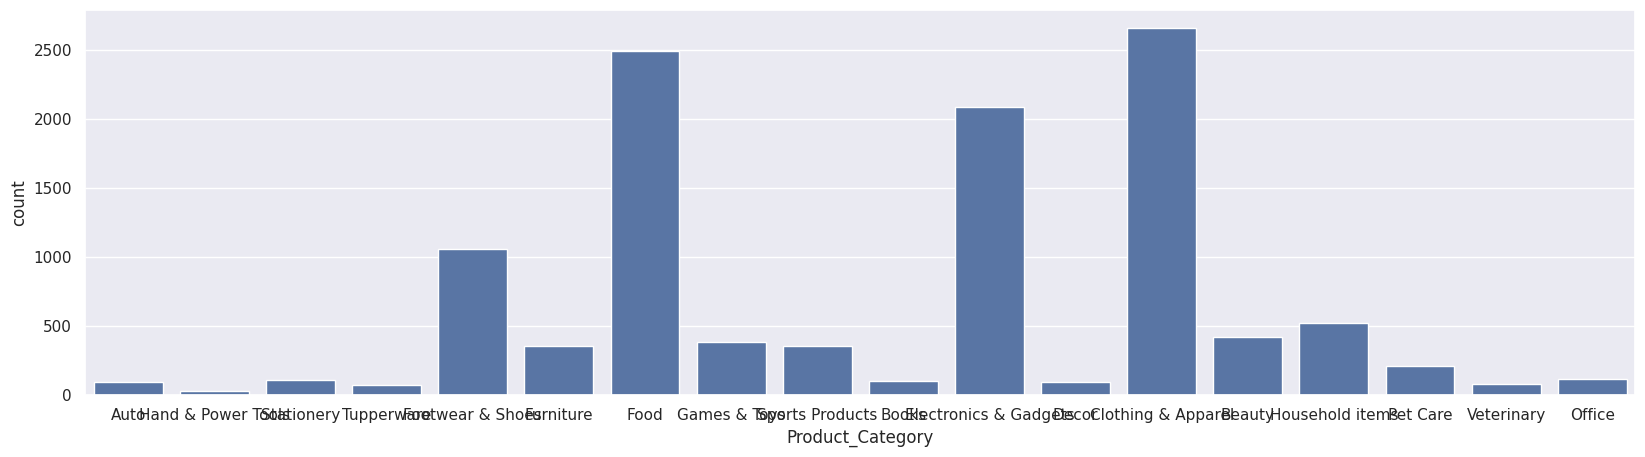

In [204]:
#Count the highest number of order??
sns.countplot(x = "Product_Category" , data =df)

##From the below graph we can see that the most of the products sold from the **Food , Clothing and Electronics..

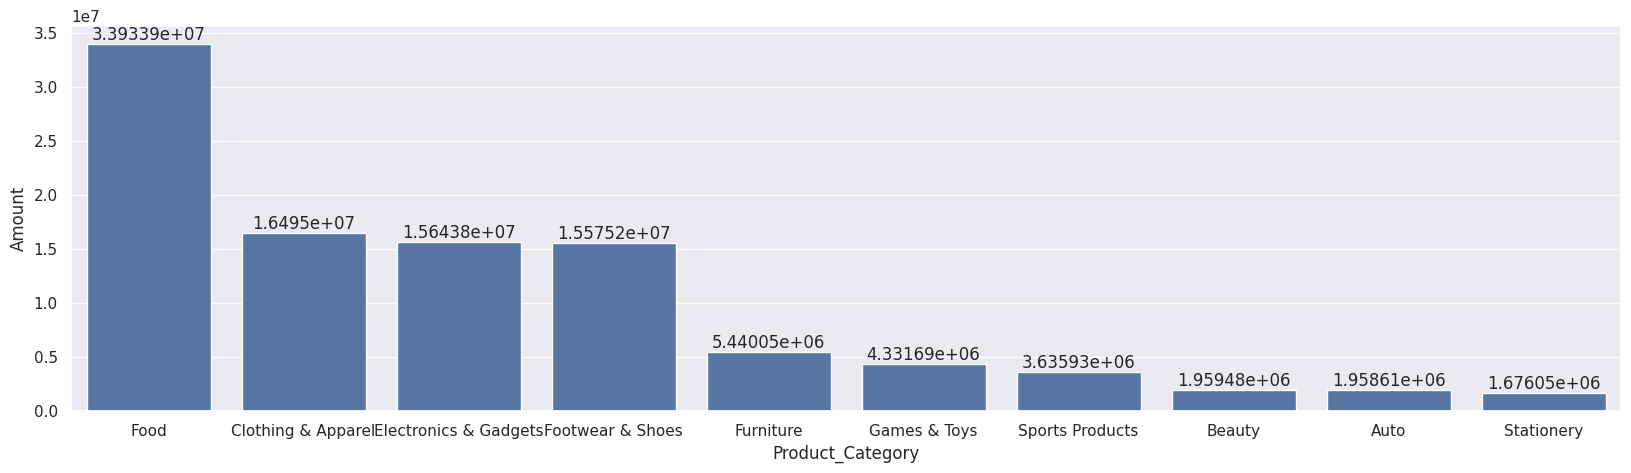

In [206]:
#Find the highest number of Product Catagory with the amount??

sales_target = df.groupby(["Product_Category"] ,as_index=False)["Amount"].sum().sort_values(by ="Amount", ascending = False).head(10)
ax = sns.barplot(x = "Product_Category" , y = "Amount" , data = sales_target)

for i in ax.containers:
  ax.bar_label(i)

##**Conclusion**

Married women are the age group 25-35 yrs from UP, Maharashtra and Karnataka working in IT , Healthcare and Aviation are more likely to buy products from Food, Clothing and Electronics Category..